In [3]:
!pip install kaggle

In [4]:
from google.colab import files
files.upload()   # upload NEW kaggle.json (the regenerated one)

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rajdeepmudiar","key":"db391bee7327689cd5f053f6fc985171"}'}

In [5]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
!kaggle datasets download -d praveengovi/emotions-dataset-for-nlp
!unzip emotions-dataset-for-nlp.zip

Dataset URL: https://www.kaggle.com/datasets/praveengovi/emotions-dataset-for-nlp
License(s): CC-BY-SA-4.0
100% 721k/721k [00:00<00:00, 1.14MB/s]

Archive:  emotions-dataset-for-nlp.zip
  inflating: test.txt                
  inflating: train.txt               
  inflating: val.txt                 


In [7]:
import pandas as pd

train = pd.read_csv("train.txt", sep=";", names=["text", "emotion"])
val = pd.read_csv("val.txt", sep=";", names=["text", "emotion"])
test = pd.read_csv("test.txt", sep=";", names=["text", "emotion"])

print(train.head())
print(train["emotion"].value_counts())

                                                text  emotion
0                            i didnt feel humiliated  sadness
1  i can go from feeling so hopeless to so damned...  sadness
2   im grabbing a minute to post i feel greedy wrong    anger
3  i am ever feeling nostalgic about the fireplac...     love
4                               i am feeling grouchy    anger
emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64


In [8]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

for df in [train, val, test]:
    df["text"] = df["text"].apply(clean_text)

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train["emotion"] = le.fit_transform(train["emotion"])
val["emotion"] = le.transform(val["emotion"])
test["emotion"] = le.transform(test["emotion"])

print("Classes:", le.classes_)

Classes: ['anger' 'fear' 'joy' 'love' 'sadness' 'surprise']


In [10]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

vocab_size = 12000
max_len = 60

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(train["text"])

X_train = pad_sequences(tokenizer.texts_to_sequences(train["text"]), maxlen=max_len, padding="post")
X_val = pad_sequences(tokenizer.texts_to_sequences(val["text"]), maxlen=max_len, padding="post")
X_test = pad_sequences(tokenizer.texts_to_sequences(test["text"]), maxlen=max_len, padding="post")

y_train = train["emotion"]
y_val = val["emotion"]
y_test = test["emotion"]

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

model = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),

    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.3),

    Bidirectional(LSTM(64)),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dense(6, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 87s 328ms/step - accuracy: 0.5171 - loss: 1.2220 - val_accuracy: 0.8245 - val_loss: 0.5167
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 75s 300ms/step - accuracy: 0.8784 - loss: 0.3498 - val_accuracy: 0.8905 - val_loss: 0.3104
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 84s 309ms/step - accuracy: 0.9379 - loss: 0.1796 - val_accuracy: 0.9125 - val_loss: 0.2629
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 73s 291ms/step - accuracy: 0.9603 - loss: 0.1135 - val_accuracy: 0.9200 - val_loss: 0.2741
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 82s 290ms/step - accuracy: 0.9663 - loss: 0.0925 - val_accuracy: 0.9155 - val_loss: 0.2510
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 73s 292ms/step - accuracy: 0.9759 - loss: 0.0698 - val_accuracy: 0.9120 - val_loss: 0.2848
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 73s 292ms/step - accuracy: 0.9779 - loss: 0.0632 - val_accuracy: 0.9205 - val_loss: 0.2875


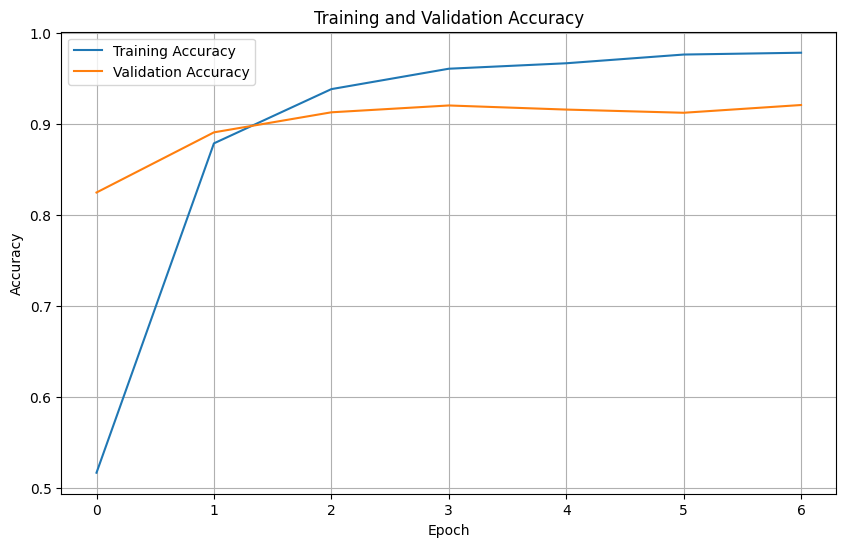

In [17]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.9165 - loss: 0.2386
Test Accuracy: 0.9164999723434448


In [14]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test).argmax(axis=1)

print(classification_report(y_test, y_pred, target_names=le.classes_))

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step
              precision    recall  f1-score   support

       anger       0.94      0.91      0.92       275
        fear       0.86      0.88      0.87       224
         joy       0.96      0.92      0.94       695
        love       0.76      0.88      0.81       159
     sadness       0.96      0.96      0.96       581
    surprise       0.69      0.77      0.73        66

    accuracy                           0.92      2000
   macro avg       0.86      0.89      0.87      2000
weighted avg       0.92      0.92      0.92      2000



In [15]:
def predict(text):
    text = clean_text(text)
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=max_len)

    pred = model.predict(padded)
    return le.inverse_transform([pred.argmax()])[0]

print(predict("I feel so happy today"))
print(predict("I am very scared right now"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
anger
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
anger


In [16]:
model.save("emotion_model.h5")